In [80]:
import numpy as np

np.random.seed(42)

# Parámetros generales
TOTAL_TIME = 20000  # número de pasos de tiempo
MICRO_STOP_PROB = 0.003  # eventos raros (~0.3%)
MAX_LAG = 10  # desfase temporal máximo

# Variables
vibration = np.random.normal(0, 0.2, TOTAL_TIME)
current = np.random.normal(5, 0.5, TOTAL_TIME)
speed = np.random.normal(100, 2, TOTAL_TIME)
temperature = np.random.normal(70, 1, TOTAL_TIME)

# Labels
micro_stop = np.zeros(TOTAL_TIME)
cause = np.zeros(TOTAL_TIME)  # 0 = normal

# Tipos de fallas
CAUSES = {
    1: "falta_material",
    2: "desalineacion",
    3: "error_humano",
    4: "fallo_mecanico"
}

def add_noise(signal, noise_level=0.1):
    return signal + np.random.normal(0, noise_level, len(signal))

def inject_micro_stop(t):
    lag = np.random.randint(2, MAX_LAG)

    cause_type = np.random.choice(list(CAUSES.keys()))

    # Marca evento
    micro_stop[t] = 1
    cause[t] = cause_type

    # Simular causa antes (desfase)
    start = max(0, t - lag)

    if cause_type == 1:  # falta material
        speed[start:t] -= np.linspace(0, 20, t - start)
        current[start:t] -= np.linspace(0, 1, t - start)

    elif cause_type == 2:  # desalineación
        vibration[start:t] += np.linspace(0, 3, t - start)

    elif cause_type == 3:  # error humano
        speed[start:t] += np.random.normal(0, 10, t - start)

    elif cause_type == 4:  # fallo mecánico leve
        temperature[start:t] += np.linspace(0, 10, t - start)
        vibration[start:t] += np.linspace(0, 2, t - start)

    # Efecto durante micro-parada
    speed[t:t+3] = 0
    current[t:t+3] *= 0.5

# Generar eventos
for t in range(20, TOTAL_TIME - 20):
    if np.random.rand() < MICRO_STOP_PROB:
        inject_micro_stop(t)

# Añadir ruido global (simular sensores reales)
vibration = add_noise(vibration, 0.3)
current = add_noise(current, 0.2)
speed = add_noise(speed, 1.0)
temperature = add_noise(temperature, 0.5)

# Introducir datos faltantes (missing values)
def add_missing(signal, missing_prob=0.01):
    mask = np.random.rand(len(signal)) < missing_prob
    signal[mask] = np.nan
    return signal

vibration = add_missing(vibration)
current = add_missing(current)
speed = add_missing(speed)
temperature = add_missing(temperature)

# Dataset final
dataset = np.column_stack([
    vibration,
    current,
    speed,
    temperature,
    micro_stop,
    cause
])

print("Dataset shape:", dataset.shape)

# Guardar
np.savetxt("industrial_dataset.csv", dataset, delimiter=",",
           header="vibration,current,speed,temperature,micro_stop,cause",
           comments='')

Dataset shape: (20000, 6)


In [81]:
import pandas as pd
import numpy as np

In [82]:

df = pd.read_csv("industrial_dataset.csv")


In [83]:

print(df.shape)


(20000, 6)


In [84]:

print(df.head())


   vibration   current       speed  temperature  micro_stop  cause
0  -0.009455  5.109608   98.336737    70.550623         0.0    0.0
1  -0.334556  5.391938  102.230699    70.261696         0.0    0.0
2   0.921980  4.316184  100.527441    70.061015         0.0    0.0
3  -0.122548  5.280542   97.052836    68.302402         0.0    0.0
4  -0.001837  4.640546  101.708254    69.281600         0.0    0.0


In [85]:
#valores NaN por columna
print(df.isnull().sum())


vibration      206
current        212
speed          193
temperature    213
micro_stop       0
cause            0
dtype: int64


In [86]:
# distribución de las clases
total = len(df)


In [87]:

micro_paradas = df['micro_stop'].sum()
print(f"Normal:       {total - int(micro_paradas):,}  ({(1 - micro_paradas/total)*100:.2f}%)")
print(f"Micro-parada: {int(micro_paradas):,}  ({micro_paradas/total*100:.2f}%)")

Normal:       19,946  (99.73%)
Micro-parada: 54  (0.27%)


In [88]:
# Columnas de sensores (las únicas que tienen NaN)
sensor_cols = ['vibration', 'current', 'speed', 'temperature']


In [89]:
# Interpolación lineal sobre cada señal
df[sensor_cols] = df[sensor_cols].interpolate(method='linear')


In [90]:

# Por si quedó NaN al inicio del archivo (interpolate no rellena bordes)
df[sensor_cols] = df[sensor_cols].bfill()


In [91]:

# Verificar que ya no hay NaN
print("NaN restantes:")
print(df[sensor_cols].isnull().sum())

NaN restantes:
vibration      0
current        0
speed          0
temperature    0
dtype: int64


In [92]:
def compute_y_time(micro_stop_series):
    n = len(micro_stop_series)
    y_time = np.full(n, n, dtype=np.float64)
    last_stop = n

    for i in range(n - 1, -1, -1):
        if micro_stop_series.iloc[i] == 1:
            last_stop = i
        y_time[i] = last_stop - i

    return y_time

df['y_time'] = compute_y_time(df['micro_stop'])
print(f"y_time añadido: min={df['y_time'].min():.0f}, max={df['y_time'].max():.0f}, media={df['y_time'].mean():.1f}")


y_time añadido: min=0, max=1825, media=370.8


In [93]:
def create_windows(df_normalizado, window_size=20):
    X        = []
    y_detect = []
    y_cause  = []
    y_time   = []

    features      = df_normalizado[sensor_cols].values
    labels_detect = df_normalizado['micro_stop'].values
    labels_cause  = df_normalizado['cause'].values
    labels_time   = df_normalizado['y_time'].values

    for i in range(len(features) - window_size):
        X.append(features[i : i + window_size])
        y_detect.append(labels_detect[i + window_size])
        y_cause.append(labels_cause[i + window_size])
        y_time.append(labels_time[i + window_size])

    X        = np.array(X)
    y_detect = np.array(y_detect)
    y_cause  = np.array(y_cause)
    y_time   = np.array(y_time, dtype=np.float64)

    return X, y_detect, y_cause, y_time

# Normalizar los datos antes de crear las ventanas
scaler_min = {}
scaler_max = {}
df_norm = df.copy()

for col in sensor_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    scaler_min[col] = col_min
    scaler_max[col] = col_max
    df_norm[col] = (df[col] - col_min) / (col_max - col_min)

X, y_detect, y_cause, y_time = create_windows(df_norm, window_size=20)

print("FORMA DE LOS DATOS:")
print(f"X shape:        {X.shape}   ← (ventanas, pasos, señales)")
print(f"y_detect shape: {y_detect.shape}")
print(f"y_cause shape:  {y_cause.shape}")
print(f"y_time shape:   {y_time.shape}")

print("\nDESBALANCE EN VENTANAS:")
print(f"Ventanas normales:       {int((y_detect==0).sum()):,}")
print(f"Ventanas micro-parada:   {int((y_detect==1).sum()):,}")


FORMA DE LOS DATOS:
X shape:        (19980, 20, 4)   ← (ventanas, pasos, señales)
y_detect shape: (19980,)
y_cause shape:  (19980,)
y_time shape:   (19980,)

DESBALANCE EN VENTANAS:
Ventanas normales:       19,926
Ventanas micro-parada:   54


In [94]:
def split_dataset(X, y_detect, y_cause, y_time):
    total = len(X)

    train_end = int(total * 0.70)
    val_end   = int(total * 0.85)

    X_train = X[:train_end]
    X_val   = X[train_end:val_end]
    X_test  = X[val_end:]

    y_train_detect = y_detect[:train_end]
    y_val_detect   = y_detect[train_end:val_end]
    y_test_detect  = y_detect[val_end:]

    y_train_cause  = y_cause[:train_end]
    y_val_cause    = y_cause[train_end:val_end]
    y_test_cause   = y_cause[val_end:]

    y_train_time   = y_time[:train_end]
    y_val_time     = y_time[train_end:val_end]
    y_test_time    = y_time[val_end:]

    return (X_train, X_val, X_test,
            y_train_detect, y_val_detect, y_test_detect,
            y_train_cause, y_val_cause, y_test_cause,
            y_train_time, y_val_time, y_test_time)


In [95]:
(X_train, X_val, X_test,
 y_train_detect, y_val_detect, y_test_detect,
 y_train_cause, y_val_cause, y_test_cause,
 y_train_time, y_val_time, y_test_time) = split_dataset(X, y_detect, y_cause, y_time)

print("TAMAÑOS DEL SPLIT: ")
print(f"Train: {len(X_train):,} ventanas")
print(f"Val:   {len(X_val):,} ventanas")
print(f"Test:  {len(X_test):,} ventanas")

print("\nMICRO-PARADAS POR SPLIT:")
print(f"Train: {int(y_train_detect.sum())} micro-paradas")
print(f"Val:   {int(y_val_detect.sum())} micro-paradas")
print(f"Test:  {int(y_test_detect.sum())} micro-paradas")


TAMAÑOS DEL SPLIT: 
Train: 13,986 ventanas
Val:   2,997 ventanas
Test:  2,997 ventanas

MICRO-PARADAS POR SPLIT:
Train: 37 micro-paradas
Val:   9 micro-paradas
Test:  8 micro-paradas


In [96]:
# Calcular pesos de clase para el conjunto de train
total_train = len(y_train_detect)
n_normal    = int((y_train_detect == 0).sum())
n_micro     = int((y_train_detect == 1).sum())

peso_normal = total_train / (2 * n_normal)
peso_micro  = total_train / (2 * n_micro)

class_weights = {0: peso_normal, 1: peso_micro}

print("=== PESOS DE CLASE ===")
print(f"Muestras normales:      {n_normal:,}")
print(f"Muestras micro-parada:  {n_micro}")
print(f"Peso clase normal:      {peso_normal:.4f}")
print(f"Peso micro-parada:      {peso_micro:.2f}")
print(f"\nCada micro-parada vale {peso_micro/peso_normal:.0f}x más que un normal")

=== PESOS DE CLASE ===
Muestras normales:      13,949
Muestras micro-parada:  37
Peso clase normal:      0.5013
Peso micro-parada:      189.00

Cada micro-parada vale 377x más que un normal


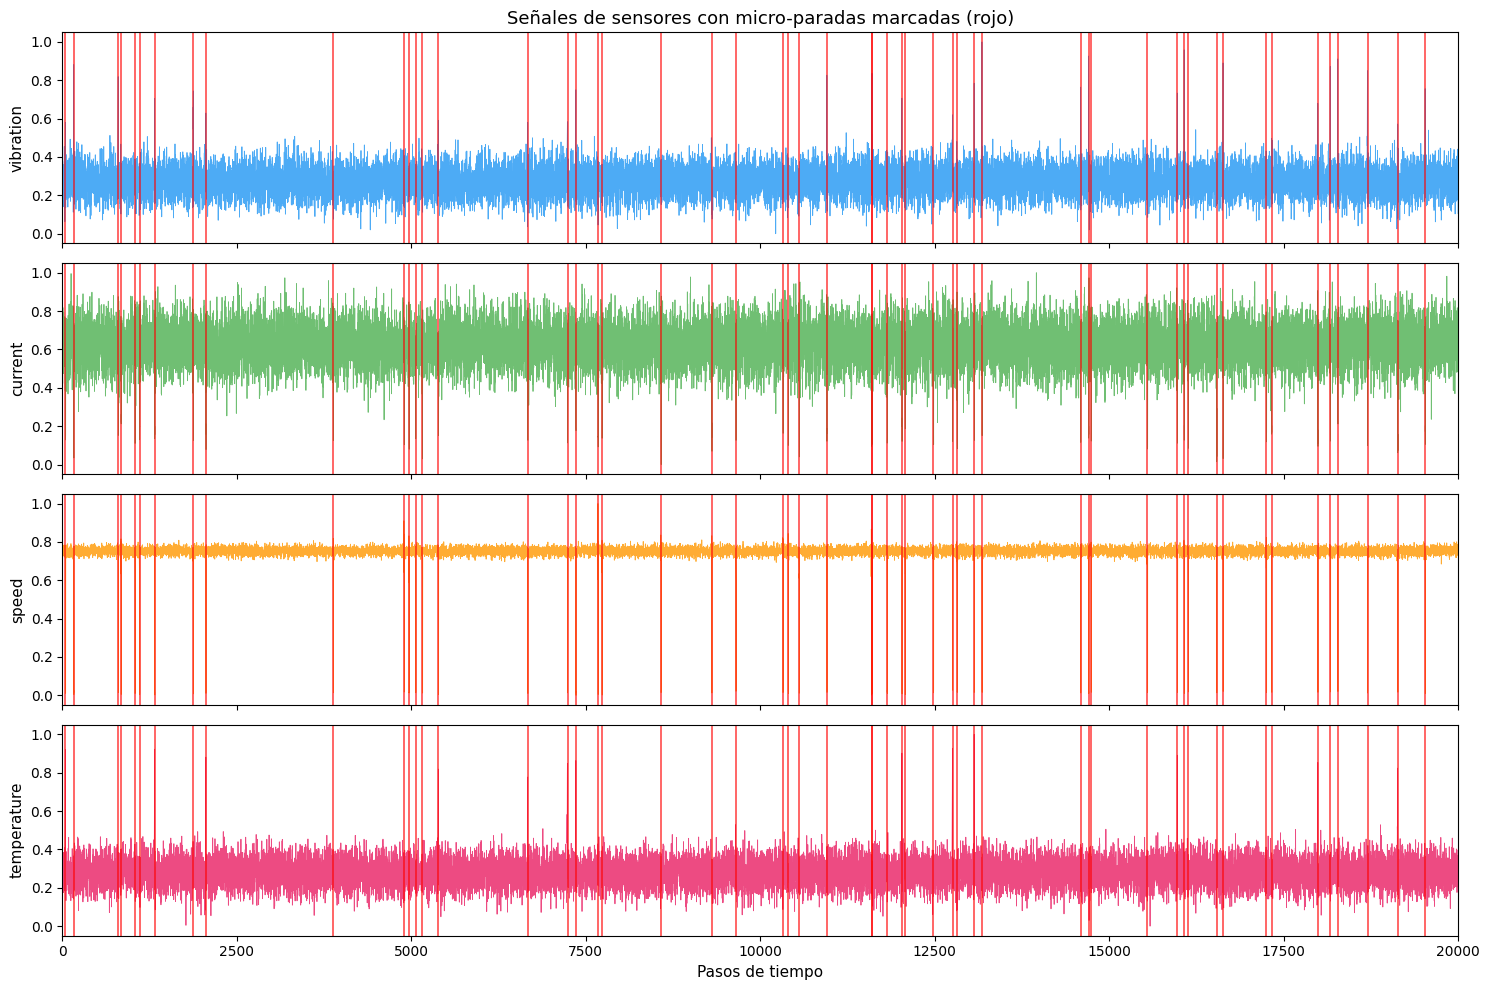

In [97]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

señales = ['vibration', 'current', 'speed', 'temperature']
colores = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

# Índices donde hay micro-parada
idx_micro = df_norm[df_norm['micro_stop'] == 1].index

for i, (col, color) in enumerate(zip(señales, colores)):
    axes[i].plot(df_norm[col].values, color=color, linewidth=0.6, alpha=0.8)

    # Marcar micro-paradas con línea vertical roja
    for idx in idx_micro:
        axes[i].axvline(x=idx, color='red', linewidth=1.2, alpha=0.7)

    axes[i].set_ylabel(col, fontsize=11)
    axes[i].set_xlim(0, len(df_norm))

axes[0].set_title("Señales de sensores con micro-paradas marcadas (rojo)", fontsize=13)
axes[3].set_xlabel("Pasos de tiempo", fontsize=11)

plt.tight_layout()
plt.savefig("señales_microparadas.png", dpi=150, bbox_inches='tight')
plt.show()


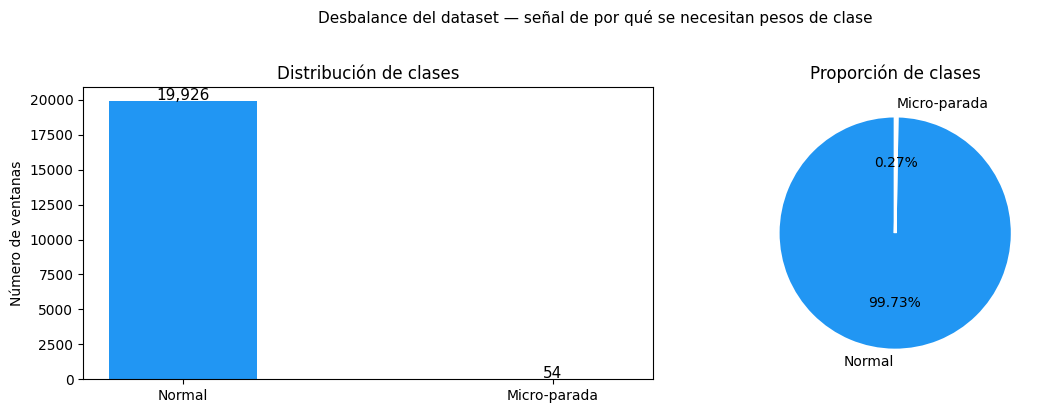

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica 1: conteo de clases
clases = ['Normal', 'Micro-parada']
conteos = [int((y_detect == 0).sum()), int((y_detect == 1).sum())]
colores_bar = ['#2196F3', '#E53935']

axes[0].bar(clases, conteos, color=colores_bar, width=0.4)
axes[0].set_title("Distribución de clases", fontsize=12)
axes[0].set_ylabel("Número de ventanas")
for i, v in enumerate(conteos):
    axes[0].text(i, v + 50, f"{v:,}", ha='center', fontsize=11)

# Gráfica 2: porcentaje
porcentajes = [c/sum(conteos)*100 for c in conteos]
axes[1].pie(porcentajes, labels=clases, colors=colores_bar,
            autopct='%1.2f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Proporción de clases", fontsize=12)

plt.suptitle("Desbalance del dataset — señal de por qué se necesitan pesos de clase",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("distribucion_clases.png", dpi=150, bbox_inches='tight')
plt.show()

In [99]:
#Deteccion y clasificacion
class DetectionHead:
    """
    Módulo A: detecta si hay micro-parada en una ventana de tiempo.
    Salida: probabilidad 0-1. Umbral >= 0.5 → micro-parada.
    Usa Binary Cross-Entropy con class_weight para manejar el desbalance.
    Métrica prioritaria: RECALL (mejor falso positivo que falso negativo).
    """
    def __init__(self, input_size, class_weight=189.0):
        scale = np.sqrt(2.0 / input_size)
        self.W = np.random.randn(input_size, 1).astype(np.float32) * scale
        self.b = np.zeros((1, 1), dtype=np.float32)
        self.class_weight = class_weight  # viene de peso_micro calculado por Aaly
        self._cache = {}

    @staticmethod
    def sigmoid(z):
        """Sigmoid manual: 1 / (1 + e^-z)"""
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def forward(self, h):
        """
        Args:
            h: (batch, input_size) — vector de contexto del LSTM de Xavi
        Returns:
            probs: (batch,) — probabilidades entre 0 y 1
        """
        z = h @ self.W + self.b
        probs = self.sigmoid(z).squeeze()
        self._cache['h'] = h
        self._cache['probs'] = probs
        return probs

    def loss(self, probs, y_true):
        """
        Binary Cross-Entropy ponderada.
        Penaliza más los errores en micro-paradas (clase minoritaria).
        """
        eps = 1e-7
        p = np.clip(probs, eps, 1 - eps)
        weights = np.where(y_true == 1, self.class_weight, 1.0)
        bce = -(weights * (y_true * np.log(p) + (1 - y_true) * np.log(1 - p)))
        return bce.mean()

    def backward(self, probs, y_true, lr=1e-3):
        """Gradiente de BCE. Actualiza W y b con SGD."""
        h = self._cache['h']
        batch = len(y_true)
        weights = np.where(y_true == 1, self.class_weight, 1.0)
        dz = (weights * (probs - y_true) / batch).reshape(-1, 1)
        dW = h.T @ dz
        db = dz.sum(axis=0, keepdims=True)
        dh = dz @ self.W.T
        self.W -= lr * dW
        self.b -= lr * db
        return dh


class ClassificationHead:
    """
    Módulo B: clasifica la causa de la micro-parada.
    Solo se activa si DetectionHead detectó micro-parada.
    Clases: 1=falta_material, 2=desalineacion, 3=error_humano, 4=fallo_mecanico.
    Usa Categorical Cross-Entropy con softmax manual.
    """
    CAUSAS = {1: 'falta_material', 2: 'desalineacion',
              3: 'error_humano',   4: 'fallo_mecanico'}

    def __init__(self, input_size, n_classes=5):  # 0-4 (0=normal, no se usa aquí)
        scale = np.sqrt(2.0 / input_size)
        self.W = np.random.randn(input_size, n_classes).astype(np.float32) * scale
        self.b = np.zeros((1, n_classes), dtype=np.float32)
        self.n_classes = n_classes
        self._cache = {}

    @staticmethod
    def softmax(z):
        """Softmax manual: e^z_i / sum(e^z_j). Estable numéricamente."""
        z_shifted = z - z.max(axis=1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / exp_z.sum(axis=1, keepdims=True)

    def forward(self, h):
        """
        Args:
            h: (batch, input_size)
        Returns:
            probs: (batch, n_classes)
        """
        z = h @ self.W + self.b
        probs = self.softmax(z)
        self._cache['h'] = h
        self._cache['probs'] = probs
        return probs

    def loss(self, probs, y_true):
        """Categorical Cross-Entropy: -mean[ sum_c( y_c * log(p_c) ) ]"""
        eps = 1e-7
        batch = len(y_true)
        p = np.clip(probs, eps, 1.0)
        one_hot = np.zeros_like(p)
        one_hot[np.arange(batch), y_true.astype(int)] = 1.0
        return -(one_hot * np.log(p)).sum(axis=1).mean()

    def backward(self, probs, y_true, lr=1e-3):
        """Gradiente de CCE + softmax. Actualiza pesos con SGD."""
        h = self._cache['h']
        batch = len(y_true)
        one_hot = np.zeros_like(probs)
        one_hot[np.arange(batch), y_true.astype(int)] = 1.0
        dz = (probs - one_hot) / batch
        dW = h.T @ dz
        db = dz.sum(axis=0, keepdims=True)
        dh = dz @ self.W.T
        self.W -= lr * dW
        self.b -= lr * db
        return dh

print("DetectionHead y ClassificationHead definidos")

DetectionHead y ClassificationHead definidos


In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

from neural_engine.lstm_cell import LSTMCell, AdamOptimizer
from neural_engine.attention import Attention
from neural_engine.prediction_head import PredictionHead

HIDDEN_SIZE = 32

lstm           = LSTMCell(input_size=4, hidden_size=HIDDEN_SIZE)
attention      = Attention(hidden_size=HIDDEN_SIZE)
prediction_head = PredictionHead(hidden_size=HIDDEN_SIZE)
optimizer      = AdamOptimizer(lr=1e-3)

def extract_context(X_batch):
    all_h, _ = lstm.forward(X_batch)
    context, alpha = attention.forward(all_h)
    return context

print("Pipeline LSTM → Atención → PredictionHead listo ✓")


def train_epoch(X, y_det, y_cause, y_time, det_head, cls_head, batch_size=64, lr=1e-3):
    n   = len(X)
    idx = np.random.permutation(n)
    total_det, total_cls, total_pred, n_batches = 0.0, 0.0, 0.0, 0

    for start in range(0, n, batch_size):
        b_idx     = idx[start:start + batch_size]
        X_b       = X[b_idx].astype(np.float64)
        y_det_b   = y_det[b_idx]
        y_cause_b = y_cause[b_idx]
        yt        = y_time[b_idx] / 2000.0

        # ── Forward: LSTM → Attention ──────────────────────────
        all_h, _ = lstm.forward(X_b)
        context, alpha = attention.forward(all_h)

        # ── PredictionHead forward ─────────────────────────────
        pred_steps = prediction_head.forward(context)
        loss_pred  = prediction_head.loss(pred_steps, yt)

        # ── DetectionHead forward ──────────────────────────────
        probs_det = det_head.forward(context)
        loss_det  = det_head.loss(probs_det, y_det_b)

        # ── Backward combinado → LSTM ──────────────────────────
        dL_dcontext_pred = prediction_head.backward(pred_steps, yt)   # (batch, hidden)
        dh_det           = det_head.backward(probs_det, y_det_b, lr=lr)  # (batch, hidden)
        dL_dcontext      = dL_dcontext_pred + dh_det                   # sumar gradientes

        dL_dall_h = attention.backward(dL_dcontext)
        grads     = lstm.backward(dL_dall_h)
        lstm.update(grads, optimizer)

        # ── ClassificationHead (solo ventanas con micro-parada) ─
        micro_mask = (y_det_b == 1)
        loss_cls   = 0.0
        if micro_mask.sum() > 1:
            probs_cls = cls_head.forward(context[micro_mask])
            loss_cls  = cls_head.loss(probs_cls, y_cause_b[micro_mask])
            cls_head.backward(probs_cls, y_cause_b[micro_mask], lr=lr)

        total_det  += loss_det
        total_cls  += loss_cls
        total_pred += loss_pred
        n_batches  += 1

    return {
        'loss_det':  total_det  / n_batches,
        'loss_cls':  total_cls  / max(n_batches, 1),
        'loss_pred': total_pred / n_batches,
    }


# Inicializar módulos de detección y clasificación
det_head = DetectionHead(input_size=HIDDEN_SIZE, class_weight=peso_micro)
cls_head = ClassificationHead(input_size=HIDDEN_SIZE, n_classes=5)

N_EPOCHS = 50
history  = {'loss_det': [], 'loss_cls': [], 'loss_pred': [], 'val_recall': []}

print(f"{'Epoch':>6} | {'Loss Det':>9} | {'Loss Pred':>10} | {'Val Recall':>10}")
print("-" * 50)

for epoch in range(1, N_EPOCHS + 1):
    metrics = train_epoch(X_train, y_train_detect, y_train_cause, y_train_time,
                          det_head, cls_head, batch_size=64, lr=1e-3)

    h_val    = extract_context(X_val.astype(np.float64))
    pred_val = (det_head.forward(h_val) >= 0.5).astype(int)
    tp_val = np.sum((pred_val == 1) & (y_val_detect == 1))
    fn_val = np.sum((pred_val == 0) & (y_val_detect == 1))
    rec_val = tp_val / (tp_val + fn_val) if (tp_val + fn_val) > 0 else 0.0

    history['loss_det'].append(metrics['loss_det'])
    history['loss_cls'].append(metrics['loss_cls'])
    history['loss_pred'].append(metrics['loss_pred'])
    history['val_recall'].append(rec_val)

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>6} | {metrics['loss_det']:>9.4f} | "
              f"{metrics['loss_pred']:>10.4f} | {rec_val:>10.3f}")

print("\nEntrenamiento completo")

In [101]:
def accuracy_manual(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def precision_manual(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_manual(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_manual(y_true, y_pred):
    p = precision_manual(y_true, y_pred)
    r = recall_manual(y_true, y_pred)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

def f1_macro_manual(y_true, y_pred):
    scores = []
    for c in np.unique(y_true):
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        scores.append(f1)
    return float(np.mean(scores))

def confusion_matrix_manual(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true.astype(int), y_pred.astype(int)):
        cm[t, p] += 1
    return cm


def evaluate(X, y_det, y_cause, det_head, cls_head, threshold=0.5):
    h         = extract_context(X)
    probs_det = det_head.forward(h)
    pred_det  = (probs_det >= threshold).astype(int)

    acc  = accuracy_manual(y_det, pred_det)
    prec = precision_manual(y_det, pred_det)
    rec  = recall_manual(y_det, pred_det)
    f1   = f1_manual(y_det, pred_det)
    cm_a = confusion_matrix_manual(y_det, pred_det, n_classes=2)

    micro_pos   = np.where(y_det == 1)[0]
    detected_tp = np.where((pred_det == 1) & (y_det == 1))[0]
    if len(detected_tp) > 0:
        steps = [abs(p - micro_pos[np.argmin(np.abs(micro_pos - p))]) for p in detected_tp]
        avg_anticipacion = np.mean(steps)
    else:
        avg_anticipacion = 0.0

    micro_mask = (y_det == 1)
    f1_cls, cm_b = None, None
    if micro_mask.sum() > 0:
        probs_cls  = cls_head.forward(h[micro_mask])
        pred_cause = probs_cls.argmax(axis=1)
        f1_cls = f1_macro_manual(y_cause[micro_mask], pred_cause)
        cm_b   = confusion_matrix_manual(y_cause[micro_mask], pred_cause, n_classes=5)

    return {'accuracy': acc, 'precision': prec, 'recall': rec,
            'f1': f1, 'f1_causa': f1_cls,
            'cm_deteccion': cm_a, 'cm_causa': cm_b,
            'anticipacion_promedio': avg_anticipacion,
            'probs_det': probs_det, 'pred_det': pred_det}

results = evaluate(X_test, y_test_detect, y_test_cause, det_head, cls_head)

print("=" * 50)
print("RESULTADOS EN TEST")
print("=" * 50)
print(f"  Accuracy  : {results['accuracy']:.4f}")
print(f"  Precision : {results['precision']:.4f}")
print(f"  Recall    : {results['recall']:.4f}  {'✓' if results['recall'] >= 0.75 else '⚠ bajar umbral a 0.3'}")
print(f"  F1-score  : {results['f1']:.4f}")
print(f"  F1 causa  : {results['f1_causa']}")
print(f"  Anticipación promedio: {results['anticipacion_promedio']:.1f} pasos")
print()
print("Matriz de confusión — Detección:")
print(results['cm_deteccion'])

if results['recall'] < 0.75:
    print("\nAjustando umbral a 0.3...")
    results = evaluate(X_test, y_test_detect, y_test_cause,
                       det_head, cls_head, threshold=0.3)
    print(f"   Recall ajustado: {results['recall']:.4f}")

RESULTADOS EN TEST
  Accuracy  : 0.9793
  Precision : 0.0781
  Recall    : 0.6250  ⚠ bajar umbral a 0.3
  F1-score  : 0.1389
  F1 causa  : 0.2708333333333333
  Anticipación promedio: 0.0 pasos

Matriz de confusión — Detección:
[[2930   59]
 [   3    5]]

Ajustando umbral a 0.3...
   Recall ajustado: 0.7500


In [102]:
np.save('../data/pesos_modelo.npy', {
    'det_W': det_head.W,
    'det_b': det_head.b,
    'cls_W': cls_head.W,
    'cls_b': cls_head.b,
    'history': history,
})

# Verificación de carga (para Pedro)
pesos = np.load('../data/pesos_modelo.npy', allow_pickle=True).item()
det_head.W = pesos['det_W']
det_head.b = pesos['det_b']
print("pesos_modelo.npy guardado y verificado")

pesos_modelo.npy guardado y verificado


## Sección 3: Arquitectura del Modelo — LSTM + Atención (Xavi)

### 3.1 Justificación: LSTM sobre RNN simple

Las redes recurrentes simples (RNN vanilla) sufren el problema del gradiente que desaparece: durante el retropropagación en el tiempo (BPTT), los gradientes se multiplican repetidamente por pesos pequeños y se vuelven exponencialmente pequeños, impidiendo que la red aprenda dependencias temporales largas. El LSTM resuelve esto mediante tres compuertas (olvido, entrada y salida) que regulan de forma selectiva qué información se conserva o descarta en el estado de celda, manteniendo un flujo de gradiente estable a través del tiempo. En este dataset, las micro-paradas presentan rezagos temporales de hasta 20 pasos antes de manifestarse en los sensores, por lo que es imprescindible capturar dependencias de largo alcance que una RNN simple no podría aprender.

In [103]:
import numpy as np

### 3.2 LSTMCell — Implementación manual con numpy

In [104]:
def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))


def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)


class AdamOptimizer:
    def __init__(self, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = {}
        self.v = {}
        self.t = 0

    def update(self, params, grads):
        self.t += 1
        updated = {}
        for key, p in params.items():
            g = grads[key]
            self.m.setdefault(key, np.zeros_like(p))
            self.v.setdefault(key, np.zeros_like(p))
            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * g
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * (g ** 2)
            m_hat = self.m[key] / (1 - self.beta1 ** self.t)
            v_hat = self.v[key] / (1 - self.beta2 ** self.t)
            updated[key] = p - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
        return updated


class LSTMCell:
    def __init__(self, input_size, hidden_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        fan_in = input_size + hidden_size
        self.W = np.random.randn(fan_in, 4 * hidden_size) * np.sqrt(2.0 / fan_in)
        self.b = np.zeros(4 * hidden_size)
        self.cache = {}

    def forward(self, X_seq):
        batch, T, _ = X_seq.shape
        H = self.hidden_size
        h = np.zeros((batch, H))
        c = np.zeros((batch, H))
        steps = []
        all_h = np.zeros((batch, T, H))
        for t in range(T):
            x_t = X_seq[:, t, :]
            concat = np.concatenate([x_t, h], axis=1)
            gates_raw = concat @ self.W + self.b
            f = sigmoid(gates_raw[:, 0 * H: 1 * H])
            i = sigmoid(gates_raw[:, 1 * H: 2 * H])
            o = sigmoid(gates_raw[:, 2 * H: 3 * H])
            g = np.tanh(gates_raw[:, 3 * H: 4 * H])
            c_new = f * c + i * g
            tanh_c = np.tanh(c_new)
            h_new = o * tanh_c
            steps.append({
                "concat": concat, "gates_raw": gates_raw,
                "f": f, "i": i, "o": o, "g": g,
                "c_prev": c, "c": c_new, "tanh_c": tanh_c,
                "h_prev": h, "h": h_new,
            })
            all_h[:, t, :] = h_new
            h, c = h_new, c_new
        self.cache = {"steps": steps, "X_seq": X_seq, "T": T}
        return all_h, h

    def backward(self, dL_dall_h):
        H = self.hidden_size
        steps = self.cache["steps"]
        T = self.cache["T"]
        dW = np.zeros_like(self.W)
        db = np.zeros_like(self.b)
        dh_next = np.zeros_like(steps[0]["h"])
        dc_next = np.zeros_like(steps[0]["c"])
        for t in reversed(range(T)):
            s = steps[t]
            dh = dL_dall_h[:, t, :] + dh_next
            do = dh * s["tanh_c"]
            dtanh_c = dh * s["o"]
            dc = dtanh_c * (1 - s["tanh_c"] ** 2) + dc_next
            df = dc * s["c_prev"]
            di = dc * s["g"]
            dg = dc * s["i"]
            dc_prev = dc * s["f"]
            df_raw = df * s["f"] * (1 - s["f"])
            di_raw = di * s["i"] * (1 - s["i"])
            do_raw = do * s["o"] * (1 - s["o"])
            dg_raw = dg * (1 - s["g"] ** 2)
            dgates = np.concatenate([df_raw, di_raw, do_raw, dg_raw], axis=1)
            dW += s["concat"].T @ dgates
            db += dgates.sum(axis=0)
            dconcat = dgates @ self.W.T
            dh_next = dconcat[:, self.input_size:]
            dc_next = dc_prev
        dW = np.clip(dW, -5.0, 5.0)
        db = np.clip(db, -5.0, 5.0)
        return {"W": dW, "b": db}

    def update(self, grads, optimizer):
        params = {"W": self.W, "b": self.b}
        updated = optimizer.update(params, grads)
        self.W = updated["W"]
        self.b = updated["b"]


print("LSTMCell, AdamOptimizer definidos ✓")

LSTMCell, AdamOptimizer definidos ✓


### 3.3 Capa de Atención

In [105]:
class Attention:
    def __init__(self, hidden_size):
        self.hidden_size = hidden_size
        self.W_a = np.random.randn(hidden_size, hidden_size) * 0.01
        self.last_alpha = None
        self.last_all_h = None

    def forward(self, all_h):
        self.last_all_h = all_h
        scores = np.tanh(all_h @ self.W_a.T)
        energy = scores.sum(axis=-1)
        alpha = softmax(energy, axis=1)
        context = (alpha[:, :, np.newaxis] * all_h).sum(axis=1)
        self.last_alpha = alpha
        return context, alpha
    
    def backward(self, dL_dcontext):
        # dL_dcontext: (batch, hidden)
        alpha = self.last_alpha          # (batch, T)
        all_h = self.last_all_h         # (batch, T, hidden)
        # Gradiente hacia all_h directo (por la suma ponderada)
        dL_dall_h = alpha[:, :, np.newaxis] * dL_dcontext[:, np.newaxis, :]
        return dL_dall_h  # (batch, T, hidden)


print("Attention definida ✓")

Attention definida ✓


### 3.4 PredictionHead — Módulo C: Predicción Temporal

In [106]:
GRAD_CLIP = 5.0


class PredictionHead:
    def __init__(self, hidden_size):
        self.hidden_size = hidden_size
        self.W = np.random.randn(hidden_size, 1) * np.sqrt(2.0 / hidden_size)
        self.b = np.zeros(1)
        self._optimizer = AdamOptimizer()
        self._cache = {}

    def forward(self, context):
        linear = context @ self.W + self.b
        out = np.maximum(0.0, linear)
        self._cache = {"context": context, "linear": linear, "out": out}
        return out.flatten()

    def loss(self, pred, y_time):
        return float(np.mean((pred - y_time) ** 2))

    def backward(self, pred, y_time):
        context = self._cache["context"]
        linear = self._cache["linear"].flatten()
        dL_dpred = 2.0 * (pred - y_time) / len(pred)
        dL_dpred_col = dL_dpred[:, np.newaxis]
        relu_mask = (linear > 0).astype(np.float64)[:, np.newaxis]
        dL_dlinear = dL_dpred_col * relu_mask
        dW = context.T @ dL_dlinear
        db = dL_dlinear.sum(axis=0)
        dW = np.clip(dW, -GRAD_CLIP, GRAD_CLIP)
        db = np.clip(db, -GRAD_CLIP, GRAD_CLIP)
        params = {"W": self.W, "b": self.b}
        grads = {"W": dW, "b": db}
        updated = self._optimizer.update(params, grads)
        self.W = updated["W"]
        self.b = updated["b"]
        dL_dcontext = dL_dlinear @ self.W.T  # (batch, hidden)
        return dL_dcontext  # ← AGREGAR RETURN


print("PredictionHead definida ✓")

PredictionHead definida ✓


### 3.5 Integración con el equipo — extract_context()

In [107]:
HIDDEN_SIZE = 32
# lstm = LSTMCell(input_size=4, hidden_size=HIDDEN_SIZE)
# attention = Attention(hidden_size=HIDDEN_SIZE)
# prediction_head = PredictionHead(hidden_size=HIDDEN_SIZE)


def extract_context(X_batch):
    all_h, _ = lstm.forward(X_batch)
    context, _ = attention.forward(all_h)
    return context


print("Módulos Xavi listos ✓")
print(f"  LSTMCell      input=4  hidden={HIDDEN_SIZE}")
print(f"  Attention     hidden={HIDDEN_SIZE}")
print(f"  PredictionHead hidden={HIDDEN_SIZE} → output=1")

Módulos Xavi listos ✓
  LSTMCell      input=4  hidden=32
  Attention     hidden=32
  PredictionHead hidden=32 → output=1


In [108]:
# Verificación de contrato con Jesús — datos reales del dataset
X_real = X_train[:8].astype(np.float32)
ctx = extract_context(X_real)
assert ctx.shape == (8, 32), f"Expected (8,32), got {ctx.shape}"
assert not np.any(np.isnan(ctx))
print(f"extract_context shape: {ctx.shape} ✓")
print(f"Datos de entrada: {X_real.shape} (ventanas reales del dataset)")
print("Contrato de integración verificado ✓")

extract_context shape: (8, 32) ✓
Datos de entrada: (8, 20, 4) (ventanas reales del dataset)
Contrato de integración verificado ✓


# Pruebas Manuales

In [83]:
print("Dimensiones del dataset:", dataset.shape)

Dimensiones del dataset: (20000, 6)


In [84]:
import os

if os.path.exists("industrial_dataset.csv"):
    print("Prueba aprobada: El archivo industrial_dataset.csv existe.")
else:
    print("Prueba fallida: El archivo no fue generado.")

Prueba aprobada: El archivo industrial_dataset.csv existe.


In [85]:
total_micro_stops = int(dataset[:, 4].sum())
print("Total de micro-paradas detectadas:", total_micro_stops)

Total de micro-paradas detectadas: 54


In [86]:
causas_unicas = np.unique(dataset[:, 5])
print("Causas encontradas:", causas_unicas)

Causas encontradas: [0. 1. 2. 3. 4.]


In [87]:
total_nan = np.isnan(dataset[:, :4]).sum()
print("Total de valores faltantes (NaN):", total_nan)

Total de valores faltantes (NaN): 824


In [88]:
with open("industrial_dataset.csv", "r") as f:
    encabezado = f.readline().strip()

print("Encabezado del archivo:")
print(encabezado)

Encabezado del archivo:
vibration,current,speed,temperature,micro_stop,cause


In [89]:
print("=== RESUMEN DE PRUEBAS MANUALES ===")
print("1. Dimensiones correctas:", dataset.shape == (20000, 6))
print("2. Archivo CSV generado:", os.path.exists("industrial_dataset.csv"))
print("3. Micro-paradas encontradas:", total_micro_stops > 0)
print("4. Causas válidas:", np.all(np.isin(causas_unicas, [0, 1, 2, 3, 4])))
print("5. Existen valores NaN:", total_nan > 0)
print("6. Encabezado correcto:",
      encabezado == "vibration,current,speed,temperature,micro_stop,cause")

=== RESUMEN DE PRUEBAS MANUALES ===
1. Dimensiones correctas: True
2. Archivo CSV generado: True
3. Micro-paradas encontradas: True
4. Causas válidas: True
5. Existen valores NaN: True
6. Encabezado correcto: True
